In [1]:
import sys
sys.path.append('/home/artemybombastic/MyGit/KD_Summer_Work/Segmentation')
from Loop import Train_model
from Model import Unet
from torchvision.transforms.functional import adjust_sharpness,adjust_contrast,to_pil_image
from Dataset import Eval_Boot_Segmentation_Dataset
import yaml
from PIL import Image
import cv2
from Batching import img2batch,batch2img,img4batch,batch4img
from torch.optim import AdamW
from torch.nn import BCELoss
import torch
from torch import nn
import torch.utils.data as data_utils
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

In [2]:
def cut_boot_from_photo(img,mask):
    sig=nn.Sigmoid()
    real_mask = (sig(mask)>(sig(mask).max()+sig(mask).min())/2) 
    return real_mask

In [3]:
option_path=fr'/home/artemybombastic/MyGit/KD_Summer_Work/config.yml'
device='cuda' if torch.cuda.is_available() else 'cpu'
device='cpu'
print(device)
with open(option_path,'r') as file_option:
    option=yaml.safe_load(file_option)



cpu


In [4]:
def bb_finder(img):
    rows=torch.any(img>0,dim=1)
    columns=torch.any(img>0,dim=0)

    r_min=torch.where(rows)[0][0]
    r_max=torch.where(rows)[0][-1]

    c_min=torch.where(columns)[0][0]
    c_max=torch.where(columns)[0][-1]

    print(r_min,r_max+1,c_min,c_max+1)
    return img[r_min:r_max+1,c_min:c_max+1]

In [5]:
eval_dataset=Eval_Boot_Segmentation_Dataset('/home/artemybombastic/MyGit/KD_Data/TransformData/low_boots',option['Segmentation']['label_path'],)
eval_dataloader=DataLoader(dataset=eval_dataset,batch_size=1,drop_last=False,shuffle=True)

In [6]:
model=Unet(3,64).to(device)

In [7]:
try:
    weights_dict=torch.load(f'/home/artemybombastic/MyGit/KD_Data/SegmData/unet_model_{device}.pth',weights_only=True)
    model.load_state_dict(weights_dict)
except:
    print('Весов нет, инициализируем новые')

In [8]:
bt=0
for batch in eval_dataloader:
    bt=batch
    break

In [9]:
pred=model(bt['img'])

In [13]:
bt['img'].shape

torch.Size([1, 3, 1024, 512])

In [10]:
a=cut_boot_from_photo(bt['img'][0],pred[0])

IndexError: index 1 is out of bounds for dimension 0 with size 1

In [ ]:
b=bb_finder(a[0])

In [ ]:
plt.imshow(b.detach())

In [ ]:
tens2pil=to_pil_image(b.float())

In [ ]:
tens2pil.size

In [ ]:
(tens2pil.size[0]/0.670)/562

In [ ]:
int(tens2pil.size[1]//(tens2pil.size[0]/562))

In [ ]:
final_image=tens2pil.resize((562,int(tens2pil.size[1]//(tens2pil.size[0]/562))))

In [ ]:
blank_image=Image.new('RGB',size=(762,1100),color=(0,0,0))

In [ ]:
blank_image.paste(final_image,(100,1100-int(tens2pil.size[1]//(tens2pil.size[0]/562))-100))

In [ ]:
final_image.size

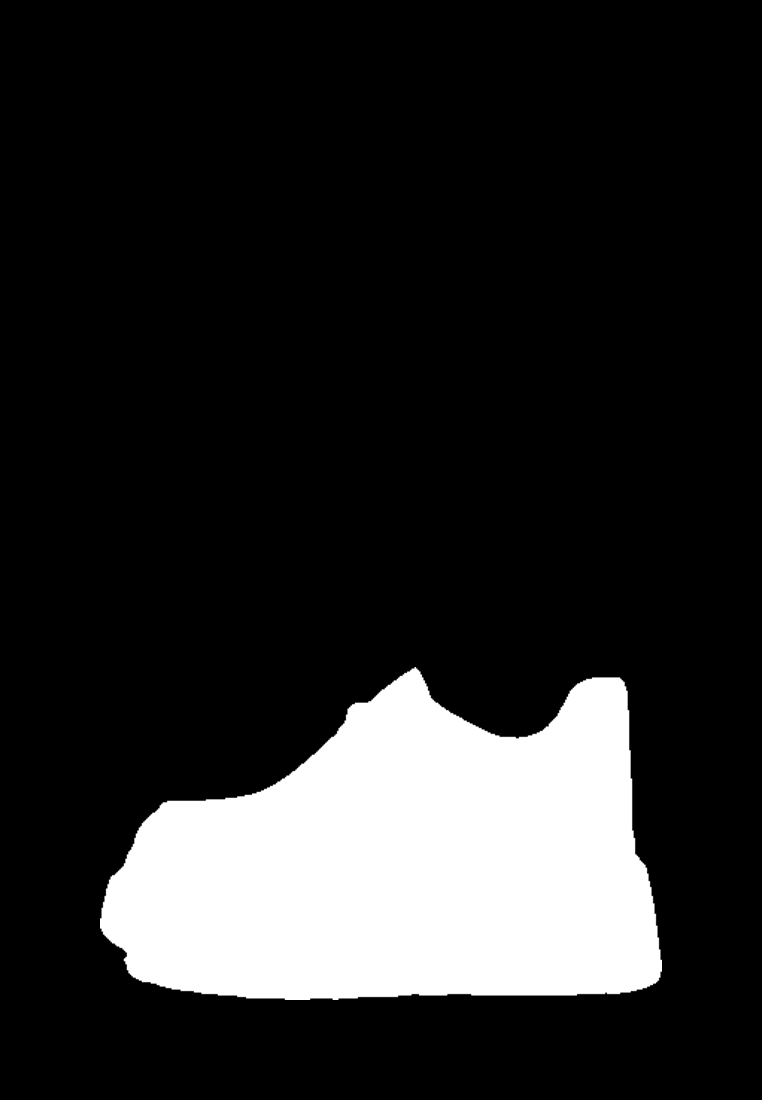

In [125]:
blank_image